In [9]:
# import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]  #This gets us to project root directory
sys.path.insert(0, str(project_root)) # modifies wher Python looks for modules when doing the import

from src.utils.config import service_client, read_adls_file

In [10]:
print(project_root)

C:\Users\jorda\OneDrive\Desktop\Code\Dev\jb_data_projects


In [ ]:
# container_client = service_client.get_file_system_client("jb-test-container")

In [11]:
def read_adls_folder(service_client, container_name, folder_path: str):
    container_client = service_client.get_file_system_client(container_name)

    results = []

    for p in container_client.get_paths(path=folder_path):
        file_client = container_client.get_file_client(p.name)

        results.append(
            read_adls_file(file_client, file_name=p.name)
        )

    return results

In [12]:
df_test = read_adls_folder(
    service_client=service_client,
    container_name="jb-test-container",
    folder_path="imgs/test"
)

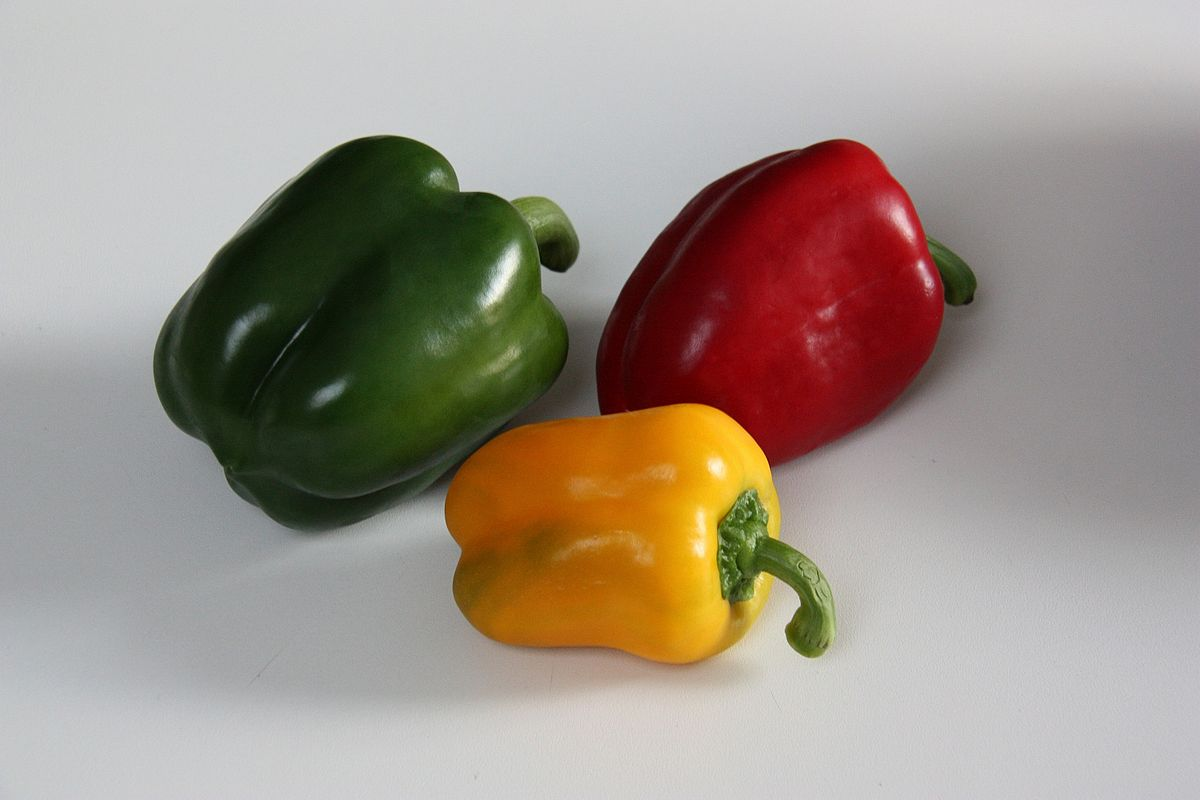

In [23]:
from IPython.display import display

img = df_test[30]["pil_image"]
display(img)